<a href="https://colab.research.google.com/github/shreyasacharya1/ML/blob/main/1BM23CS320_Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/housing.csv')

print(df.head())

Dataset loaded successfully. First 5 rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [ ]:
print("First 10 rows of the dataset:")
print(df.head(10))

print("\nData types of all attributes:")
df.info()

First 10 rows of the dataset:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   
5    -122.25     37.85                52.0        919.0           213.0   
6    -122.25     37.84                52.0       2535.0           489.0   
7    -122.25     37.84                52.0       3104.0           687.0   
8    -122.26     37.84                42.0       2555.0           665.0   
9    -122.25     37.84                52.0       3549.0           707.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0     

In [ ]:
print("Basic statistics for numeric attributes:")
print(df.describe())

Basic statistics for numeric attributes:
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.0000

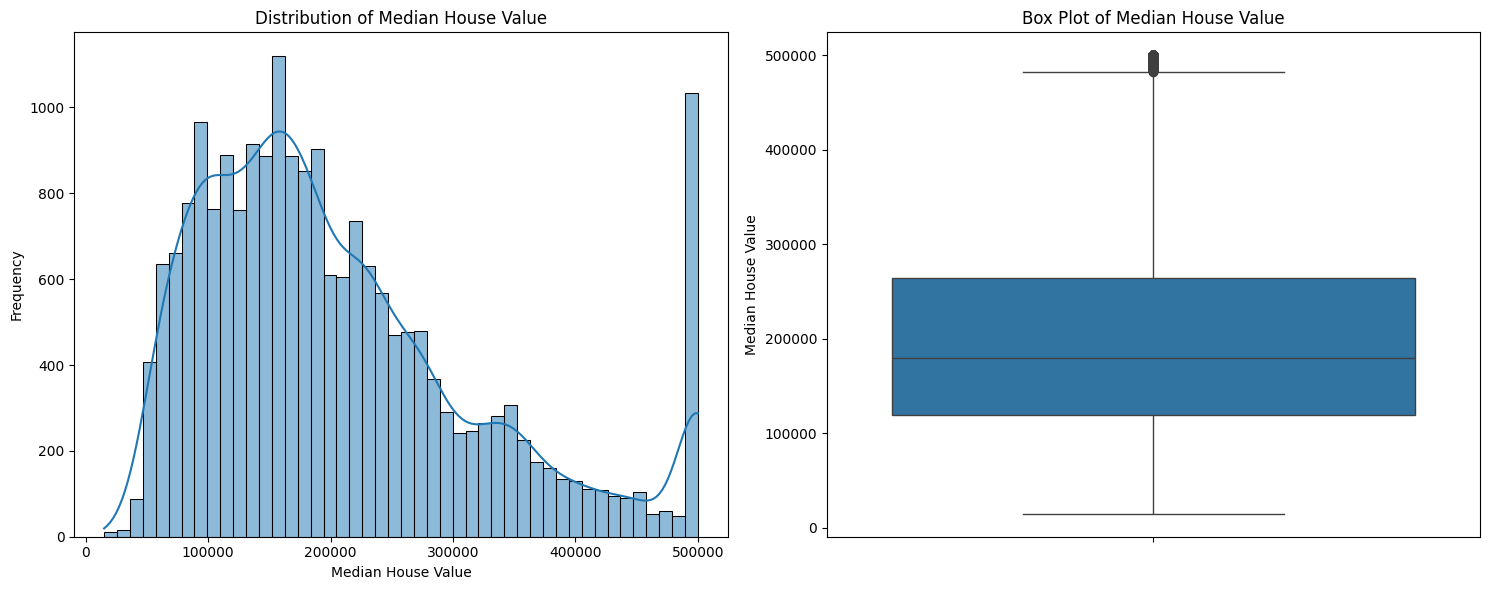

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df['median_house_value'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('Median House Value')
axes[0].set_ylabel('Frequency')


sns.boxplot(y=df['median_house_value'], ax=axes[1])
axes[1].set_title('Box Plot of Median House Value')
axes[1].set_ylabel('Median House Value')


plt.tight_layout()
plt.show()

In [ ]:
missing_values = df.isnull().sum()
missing_percentage = 100 * df.isnull().sum() / len(df)

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})


missing_df = missing_df[missing_df['Missing Count'] > 0]

print("Missing values and their percentages:")
print(missing_df)

Missing values and their percentages:
                Missing Count  Missing Percentage
total_bedrooms            207            1.002907


In [ ]:
median_total_bedrooms = df['total_bedrooms'].median()
print(f"Median of 'total_bedrooms': {median_total_bedrooms}")

df['total_bedrooms'] = df['total_bedrooms'].fillna(median_total_bedrooms)
print("Missing values in 'total_bedrooms' filled with median.")

print("Number of missing values in 'total_bedrooms' after imputation:")
print(df['total_bedrooms'].isnull().sum())

Median of 'total_bedrooms': 435.0
Missing values in 'total_bedrooms' filled with median.
Number of missing values in 'total_bedrooms' after imputation:
0


In [ ]:
from sklearn.preprocessing import OneHotEncoder


ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)


ocean_proximity_encoded = ohe.fit_transform(df[['ocean_proximity']])

ocean_proximity_df = pd.DataFrame(
    ocean_proximity_encoded,
    columns=ohe.get_feature_names_out(['ocean_proximity']),
    index=df.index
)


df = pd.concat([df.drop('ocean_proximity', axis=1), ocean_proximity_df], axis=1)

print("One-hot encoding applied to 'ocean_proximity'. First 5 rows of the updated DataFrame:")
print(df.head())
print("\nUpdated DataFrame info:")
df.info()

One-hot encoding applied to 'ocean_proximity'. First 5 rows of the updated DataFrame:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  \
0       322.0       126.0         8.3252            452600.0   
1      2401.0      1138.0         8.3014            358500.0   
2       496.0       177.0         7.2574            352100.0   
3       558.0       219.0         5.6431            341300.0   
4       565.0       259.0         3.8462            342200.0   

   ocean_proximity_<1H OCEAN  ocean_proximity_INLAND  ocean_proximity_ISLAND  

In [ ]:
from sklearn.preprocessing import MinMaxScaler


numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()



features_to_scale = [col for col in numeric_cols if not col.startswith('ocean_proximity_')]


scaler = MinMaxScaler(feature_range=(0, 1))


df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("MinMax scaling applied to numeric features. First 5 rows of the updated DataFrame:")
print(df.head())

MinMax scaling applied to numeric features. First 5 rows of the updated DataFrame:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0   0.211155  0.567481            0.784314     0.022331        0.019863   
1   0.212151  0.565356            0.392157     0.180503        0.171477   
2   0.210159  0.564293            1.000000     0.037260        0.029330   
3   0.209163  0.564293            1.000000     0.032352        0.036313   
4   0.209163  0.564293            1.000000     0.041330        0.043296   

   population  households  median_income  median_house_value  \
0    0.008941    0.020556       0.539668            0.902266   
1    0.067210    0.186976       0.538027            0.708247   
2    0.013818    0.028943       0.466028            0.695051   
3    0.015555    0.035849       0.354699            0.672783   
4    0.015752    0.042427       0.230776            0.674638   

   ocean_proximity_<1H OCEAN  ocean_proximity_INLAND  ocean_proximity_ISLAND  \
0

In [ ]:
import numpy as np


df["income_cat"] = np.ceil(df["median_income"] / 1.5)

df["income_cat"].where(df["income_cat"] < 5, 5.0, inplace=True)

print("Income categories created. First 5 rows with 'income_cat':")
print(df[['median_income', 'income_cat']].head())
print("\nValue counts of 'income_cat':")
print(df['income_cat'].value_counts())


Income categories created. First 5 rows with 'income_cat':
   median_income  income_cat
0       0.539668         1.0
1       0.538027         1.0
2       0.466028         1.0
3       0.354699         1.0
4       0.230776         1.0

Value counts of 'income_cat':
income_cat
1.0    20628
0.0       12
Name: count, dtype: int64


/tmp/ipython-input-3361609358.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["income_cat"].where(df["income_cat"] < 5, 5.0, inplace=True)


In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit


df["income_cat"] = np.ceil(df["median_income"] / 1.5)
# Cap categories at 5
df["income_cat"] = df["income_cat"].where(df["income_cat"] < 5, 5.0)

print("Income categories created. First 5 rows with 'income_cat':")
print(df[['median_income', 'income_cat']].head())
print("\nValue counts of 'income_cat':")
print(df['income_cat'].value_counts())

# Instantiate StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Perform stratified split
for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

# Drop the temporary 'income_cat' column from both sets
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

print("\nDataset split into training and test sets using stratified sampling.")
print(f"Shape of training set: {strat_train_set.shape}")
print(f"Shape of test set: {strat_test_set.shape}")

Income categories created. First 5 rows with 'income_cat':
   median_income  income_cat
0       0.539668         1.0
1       0.538027         1.0
2       0.466028         1.0
3       0.354699         1.0
4       0.230776         1.0

Value counts of 'income_cat':
income_cat
1.0    20628
0.0       12
Name: count, dtype: int64

Dataset split into training and test sets using stratified sampling.
Shape of training set: (16512, 14)
Shape of test set: (4128, 14)


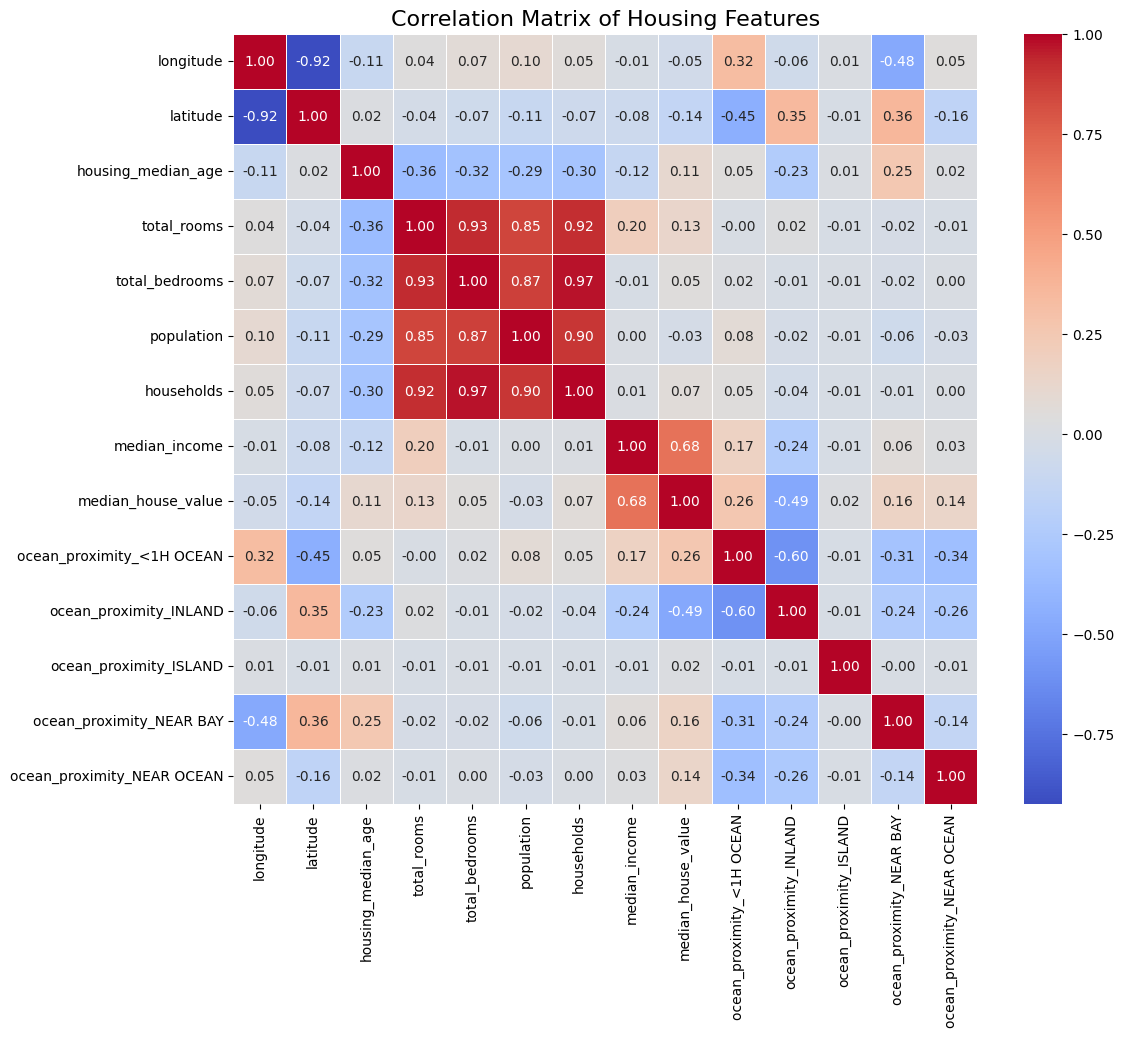

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
corr_matrix = strat_train_set.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)

# Add a title
plt.title('Correlation Matrix of Housing Features', fontsize=16)

# Display the plot
plt.show()

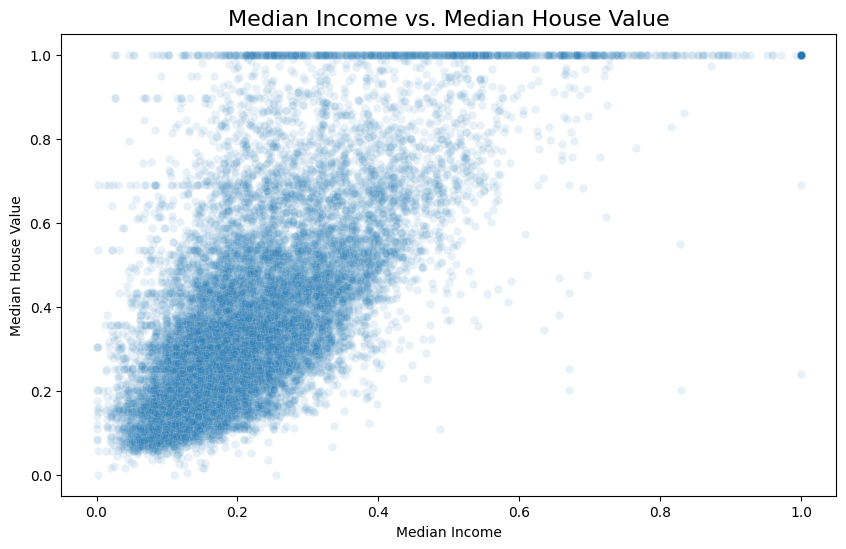

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='median_income', y='median_house_value', data=strat_train_set, alpha=0.1)
plt.title('Median Income vs. Median House Value', fontsize=16)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Divide the dataset into 80% training and 20% testing sets using random sampling
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dataset split into random training and test sets.")
print(f"Shape of X_train_random: {X_train_random.shape}")
print(f"Shape of y_train_random: {y_train_random.shape}")
print(f"Shape of X_test_random: {X_test_random.shape}")
print(f"Shape of y_test_random: {y_test_random.shape}")

Dataset split into random training and test sets.
Shape of X_train_random: (16512, 14)
Shape of y_train_random: (16512,)
Shape of X_test_random: (4128, 14)
Shape of y_test_random: (4128,)


In [ ]:
correlation_with_target = corr_matrix['median_house_value'].sort_values(ascending=False)

print("Features correlated with median_house_value:")
print(correlation_with_target)

# Get top 3 most positively correlated features (excluding median_house_value itself)
top_3_positive_corr = correlation_with_target[1:4] # Exclude self-correlation at index 0

# Get the single most negatively correlated feature
most_negative_corr = correlation_with_target.iloc[-1]

print(f"\nTop 3 most positively correlated features with 'median_house_value':\n{top_3_positive_corr}")
print(f"\nMost negatively correlated feature with 'median_house_value':\n{most_negative_corr}")

Features correlated with median_house_value:
median_house_value            1.000000
median_income                 0.684522
ocean_proximity_<1H OCEAN     0.257341
ocean_proximity_NEAR BAY      0.163476
ocean_proximity_NEAR OCEAN    0.138811
total_rooms                   0.134857
housing_median_age            0.108507
households                    0.066748
total_bedrooms                0.051847
ocean_proximity_ISLAND        0.022079
population                   -0.025470
longitude                    -0.047032
latitude                     -0.142891
ocean_proximity_INLAND       -0.486256
Name: median_house_value, dtype: float64

Top 3 most positively correlated features with 'median_house_value':
median_income                0.684522
ocean_proximity_<1H OCEAN    0.257341
ocean_proximity_NEAR BAY     0.163476
Name: median_house_value, dtype: float64

Most negatively correlated feature with 'median_house_value':
-0.4862560889370205


In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale, excluding the one-hot encoded 'ocean_proximity' features
numeric_features_to_scale = [col for col in X_train_random.columns if X_train_random[col].dtype in ['float64', 'int64'] and not col.startswith('ocean_proximity_')]


# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the numerical features of the training data
scaler.fit(X_train_random[numeric_features_to_scale])

# Transform the numerical features in both training and test sets
X_train_random[numeric_features_to_scale] = scaler.transform(X_train_random[numeric_features_to_scale])
X_test_random[numeric_features_to_scale] = scaler.transform(X_test_random[numeric_features_to_scale])

print("Standard Scaling applied to numerical features.")
print("First 5 rows of transformed X_train_random:")
print(X_train_random.head())

Standard Scaling applied to numerical features.
First 5 rows of transformed X_train_random:
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
14196   1.272587 -1.372811            0.348490     0.222569        0.211228   
8267    0.709162 -0.876696            1.618118     0.340293        0.593094   
17445  -0.447603 -0.460146           -1.952710    -0.342597       -0.495226   
14265   1.232698 -1.382172            0.586545    -0.561490       -0.409306   
2271   -0.108551  0.532084            1.142008    -0.119565       -0.256559   

       population  households  median_income  ocean_proximity_<1H OCEAN  \
14196    0.768276    0.322906      -0.326196                        0.0   
8267    -0.098901    0.672027      -0.035843                        0.0   
17445   -0.449818   -0.430461       0.144701                        0.0   
14265   -0.007434   -0.380587      -1.017864                        0.0   
2271    -0.485877   -0.314962      -0.171488              

In [ ]:
from sklearn.linear_model import LinearRegression

# Instantiate a Linear Regression model
lin_reg_model = LinearRegression()

# Train the model using the preprocessed training data
lin_reg_model.fit(X_train_random, y_train_random)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred_random = lin_reg_model.predict(X_test_random)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test_random, y_pred_random)
mse = mean_squared_error(y_test_random, y_pred_random)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_random, y_pred_random)

# Display the metrics
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.1044
Mean Squared Error (MSE): 0.0208
Root Mean Squared Error (RMSE): 0.1442
R2 Score: 0.6269
